# Experiment 3: Ablation Studies

Building on the results from our previous experiments where BERT demonstrated the best performance, we use it as our primary baseline. This section explores two main ablation studies to further understand the impact of different configurations on model performance:
* **Ablation 1:** Frozen vs. Unfrozen base model parameters (using our best-performing BERT model).
* **Ablation 2:** Different pre-trained model variants (comparing our BERT baseline against RoBERTa and DistilBERT).

In [ ]:
import os

if os.getcwd().split('/')[-1] == 'notebooks' or os.getcwd().split('\\')[-1] == 'notebooks':
    os.chdir('..')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score

from src.preprocessing import get_preprocessed_data

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Loading and Context Generation

Load the pre-processed splits and create the combined sequence context combining the question and the interview answer.

In [5]:
train_df, val_df, test_df, id2label, label2id = get_preprocessed_data()

for df in [train_df, val_df, test_df]:
    df['sub_q_context'] = df['question'].fillna('') + " [SEP] " + df['interview_answer'].fillna('')

NUM_CLASSES = len(np.unique(train_df['evasion_label']))
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_CLASSES}")

Train: 2758, Val: 690, Classes: 9


## Utilities and PyTorch Dataset

Define helper functions to track trainable parameters and GPU memory, alongside the custom Dataset class for text tokenization.

In [6]:
def count_parameters(model, only_trainable=True):
    if only_trainable:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

def gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024 ** 2
    return 0.0

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

class EvasionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

## Main Training Pipeline

This reusable function handles the initialization, training, and evaluation for a given model architecture, including the logic for freezing base layers.

In [7]:
def run_experiment(experiment_name, model_id, freeze_base=False, epochs=20, batch_size=16, lr=2e-5, max_len=128):
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        
    print(f"\n{'='*50}")
    print(f"Running: {experiment_name} | Model: {model_id} | Frozen: {freeze_base}")
    print(f"{'='*50}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    train_dataset = EvasionDataset(train_df["sub_q_context"], train_df["evasion_label"], tokenizer, max_length=max_len)
    val_dataset = EvasionDataset(val_df["sub_q_context"], val_df["evasion_label"], tokenizer, max_length=max_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=NUM_CLASSES).to(device)
    
    if freeze_base:
        for param in model.base_model.parameters():
            param.requires_grad = False
        print("-> Base model parameters frozen. Only classifier is training.")
    
    trainable_params = count_parameters(model, only_trainable=True)
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    
    reset_gpu_memory()
    t0_train = time.time()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            
            total_loss += loss.item()
            
        print(f"  [{experiment_name}] Epoch {epoch+1}/{epochs} | Loss = {total_loss/len(train_loader):.4f}")
        
    train_time = time.time() - t0_train
    gpu_mem = gpu_memory_mb()
    
    model.eval()
    all_preds, all_labels = [], []
    t0_infer = time.time()
    
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = model(**batch).logits.argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(batch["labels"].cpu().tolist())
            
    infer_time = time.time() - t0_infer
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    
    print(f"-> F1 Val: {macro_f1:.4f} | Train Time: {train_time:.1f}s | Params: {trainable_params:,}")
    
    del model, optimizer, scheduler, train_loader, val_loader
    torch.cuda.empty_cache()
    
    return {
        "Experiment": experiment_name,
        "Model": model_id,
        "Frozen Base": freeze_base,
        "Evasion F1 (Macro)": round(macro_f1, 4),
        "Train Time (s)": round(train_time, 2),
        "Inference Speed (samples/s)": round(len(val_df) / infer_time, 1),
        "GPU Memory (MB)": round(gpu_mem, 1),
        "Trainable Params": trainable_params
    }

## Execution

Run the baseline model followed by the targeted ablations.

In [8]:
ablation_results = []

res_bert_unfrozen = run_experiment(
    experiment_name="BERT (Unfrozen)", 
    model_id="bert-base-uncased", 
    freeze_base=False, 
    epochs=20
)
ablation_results.append(res_bert_unfrozen)

res_bert_frozen = run_experiment(
    experiment_name="BERT (Frozen)", 
    model_id="bert-base-uncased", 
    freeze_base=True, 
    epochs=20
)
ablation_results.append(res_bert_frozen)

res_roberta = run_experiment(
    experiment_name="RoBERTa (Unfrozen)", 
    model_id="roberta-base", 
    freeze_base=False, 
    epochs=20
)
ablation_results.append(res_roberta)

res_distilbert = run_experiment(
    experiment_name="DistilBERT (Unfrozen)", 
    model_id="distilbert-base-uncased", 
    freeze_base=False, 
    epochs=20
)
ablation_results.append(res_distilbert)


Running: BERT (Unfrozen) | Model: bert-base-uncased | Frozen: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [BERT (Unfrozen)] Epoch 1/20 | Loss = 2.1116
  [BERT (Unfrozen)] Epoch 2/20 | Loss = 1.8424
  [BERT (Unfrozen)] Epoch 3/20 | Loss = 1.7305
  [BERT (Unfrozen)] Epoch 4/20 | Loss = 1.5472
  [BERT (Unfrozen)] Epoch 5/20 | Loss = 1.2901
  [BERT (Unfrozen)] Epoch 6/20 | Loss = 1.0766
  [BERT (Unfrozen)] Epoch 7/20 | Loss = 0.8217
  [BERT (Unfrozen)] Epoch 8/20 | Loss = 0.6175
  [BERT (Unfrozen)] Epoch 9/20 | Loss = 0.4555
  [BERT (Unfrozen)] Epoch 10/20 | Loss = 0.3313
  [BERT (Unfrozen)] Epoch 11/20 | Loss = 0.2380
  [BERT (Unfrozen)] Epoch 12/20 | Loss = 0.1791
  [BERT (Unfrozen)] Epoch 13/20 | Loss = 0.1364
  [BERT (Unfrozen)] Epoch 14/20 | Loss = 0.1073
  [BERT (Unfrozen)] Epoch 15/20 | Loss = 0.0860
  [BERT (Unfrozen)] Epoch 16/20 | Loss = 0.0715
  [BERT (Unfrozen)] Epoch 17/20 | Loss = 0.0605
  [BERT (Unfrozen)] Epoch 18/20 | Loss = 0.0528
  [BERT (Unfrozen)] Epoch 19/20 | Loss = 0.0515
  [BERT (Unfrozen)] Epoch 20/20 | Loss = 0.0460
-> F1 Val: 0.3234 | Train Time: 149.5s | Params: 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [RoBERTa (Unfrozen)] Epoch 1/20 | Loss = 2.0171
  [RoBERTa (Unfrozen)] Epoch 2/20 | Loss = 1.7882
  [RoBERTa (Unfrozen)] Epoch 3/20 | Loss = 1.6052
  [RoBERTa (Unfrozen)] Epoch 4/20 | Loss = 1.4089
  [RoBERTa (Unfrozen)] Epoch 5/20 | Loss = 1.1609
  [RoBERTa (Unfrozen)] Epoch 6/20 | Loss = 0.9302
  [RoBERTa (Unfrozen)] Epoch 7/20 | Loss = 0.6991
  [RoBERTa (Unfrozen)] Epoch 8/20 | Loss = 0.5280
  [RoBERTa (Unfrozen)] Epoch 9/20 | Loss = 0.3957
  [RoBERTa (Unfrozen)] Epoch 10/20 | Loss = 0.3071
  [RoBERTa (Unfrozen)] Epoch 11/20 | Loss = 0.2334
  [RoBERTa (Unfrozen)] Epoch 12/20 | Loss = 0.1872
  [RoBERTa (Unfrozen)] Epoch 13/20 | Loss = 0.1441
  [RoBERTa (Unfrozen)] Epoch 14/20 | Loss = 0.1152
  [RoBERTa (Unfrozen)] Epoch 15/20 | Loss = 0.1014
  [RoBERTa (Unfrozen)] Epoch 16/20 | Loss = 0.0916
  [RoBERTa (Unfrozen)] Epoch 17/20 | Loss = 0.0699
  [RoBERTa (Unfrozen)] Epoch 18/20 | Loss = 0.0574
  [RoBERTa (Unfrozen)] Epoch 19/20 | Loss = 0.0453
  [RoBERTa (Unfrozen)] Epoch 20/20 | Los

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [DistilBERT (Unfrozen)] Epoch 1/20 | Loss = 2.0465
  [DistilBERT (Unfrozen)] Epoch 2/20 | Loss = 1.8340
  [DistilBERT (Unfrozen)] Epoch 3/20 | Loss = 1.7062
  [DistilBERT (Unfrozen)] Epoch 4/20 | Loss = 1.5195
  [DistilBERT (Unfrozen)] Epoch 5/20 | Loss = 1.2637
  [DistilBERT (Unfrozen)] Epoch 6/20 | Loss = 1.0300
  [DistilBERT (Unfrozen)] Epoch 7/20 | Loss = 0.7942
  [DistilBERT (Unfrozen)] Epoch 8/20 | Loss = 0.6132
  [DistilBERT (Unfrozen)] Epoch 9/20 | Loss = 0.4569
  [DistilBERT (Unfrozen)] Epoch 10/20 | Loss = 0.3555
  [DistilBERT (Unfrozen)] Epoch 11/20 | Loss = 0.2748
  [DistilBERT (Unfrozen)] Epoch 12/20 | Loss = 0.2114
  [DistilBERT (Unfrozen)] Epoch 13/20 | Loss = 0.1694
  [DistilBERT (Unfrozen)] Epoch 14/20 | Loss = 0.1351
  [DistilBERT (Unfrozen)] Epoch 15/20 | Loss = 0.1121
  [DistilBERT (Unfrozen)] Epoch 16/20 | Loss = 0.0961
  [DistilBERT (Unfrozen)] Epoch 17/20 | Loss = 0.0780
  [DistilBERT (Unfrozen)] Epoch 18/20 | Loss = 0.0687
  [DistilBERT (Unfrozen)] Epoch 19/20

## Results and Visualization

Export the aggregated metrics and generate comparison charts for F1 scores, computational time, and memory footprint.



===== ABLATION STUDIES RESULTS =====
           Experiment                   Model  Frozen Base  Evasion F1 (Macro)  Train Time (s)  Inference Speed (samples/s)  GPU Memory (MB) Trainable Params
      BERT (Unfrozen)       bert-base-uncased        False              0.3234          149.48                       1193.2           2537.3      109,489,161
        BERT (Frozen)       bert-base-uncased         True              0.0522           50.99                       1190.9            502.3            6,921
   RoBERTa (Unfrozen)            roberta-base        False              0.3725          155.20                       1193.4           2715.6      124,652,553
DistilBERT (Unfrozen) distilbert-base-uncased        False              0.3349           78.86                       2289.6           1438.6       66,960,393


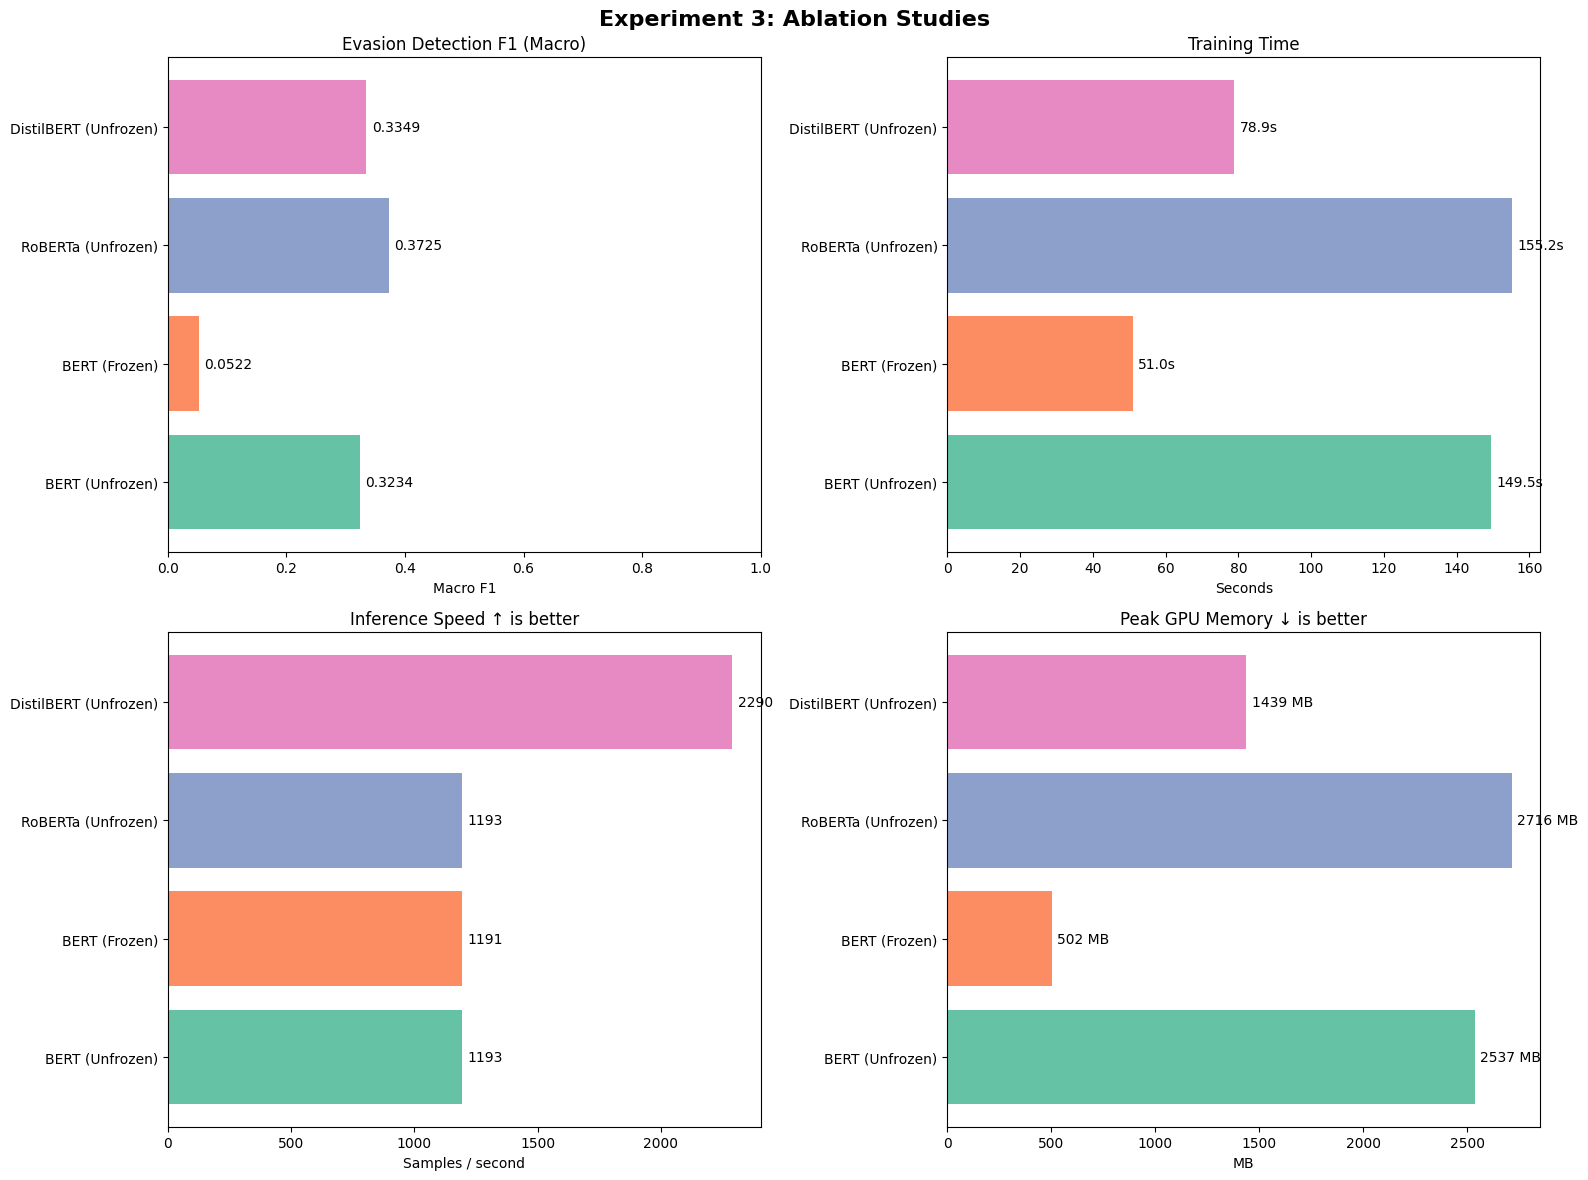


Figure saved → figures/ablation_studies.png
Table  saved → results/ablation_studies.csv


In [ ]:
results_df = pd.DataFrame(ablation_results)
results_df["Trainable Params"] = results_df["Trainable Params"].apply(lambda x: f"{x:,}")

print("\n\n===== ABLATION STUDIES RESULTS =====")
print(results_df.to_string(index=False))
results_df.to_csv("results/ablation_studies.csv", index=False)

metrics_num = pd.DataFrame(ablation_results)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Experiment 3: Ablation Studies", fontsize=16, fontweight="bold")

palette = sns.color_palette("Set2", len(ablation_results))
exps = metrics_num["Experiment"]

ax = axes[0, 0]
bars = ax.barh(exps, metrics_num["Evasion F1 (Macro)"], color=palette)
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlabel("Macro F1")
ax.set_title("Evasion Detection F1 (Macro)")
ax.set_xlim(0, 1.0)

ax = axes[0, 1]
bars = ax.barh(exps, metrics_num["Train Time (s)"], color=palette)
ax.bar_label(bars, fmt="%.1fs", padding=4)
ax.set_xlabel("Seconds")
ax.set_title("Training Time")

ax = axes[1, 0]
bars = ax.barh(exps, metrics_num["Inference Speed (samples/s)"], color=palette)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_xlabel("Samples / second")
ax.set_title("Inference Speed ↑ is better")

ax = axes[1, 1]
bars = ax.barh(exps, metrics_num["GPU Memory (MB)"], color=palette)
ax.bar_label(bars, fmt="%.0f MB", padding=4)
ax.set_xlabel("MB")
ax.set_title("Peak GPU Memory ↓ is better")

plt.tight_layout()
plt.savefig("figures/ablation_studies.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigure saved → figures/ablation_studies.png")
print("Table  saved → results/ablation_studies.csv")

## Hyperparameter Tuning (Grid Search)

Based on the ablation studies, RoBERTa emerged as the top-performing architecture. In this section, we perform a grid search over key hyperparameters (Learning Rate and Batch Size) to squeeze out the maximum performance from the `roberta-base` model. 

We will reuse our previously defined `run_experiment` function to systematically train and evaluate each combination.

In [10]:
import itertools

learning_rates = [1e-5, 2e-5, 5e-5]
batch_sizes = [16, 32]
tuning_epochs = 20

tuning_results = []

for lr, bs in itertools.product(learning_rates, batch_sizes):
    exp_name = f"RoBERTa_LR-{lr}_BS-{bs}"
    
    res = run_experiment(
        experiment_name=exp_name,
        model_id="roberta-base",
        freeze_base=False,
        epochs=tuning_epochs,
        batch_size=bs,
        lr=lr
    )
    
    res["Learning Rate"] = lr
    res["Batch Size"] = bs
    
    tuning_results.append(res)


Running: RoBERTa_LR-1e-05_BS-16 | Model: roberta-base | Frozen: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [RoBERTa_LR-1e-05_BS-16] Epoch 1/20 | Loss = 2.0661
  [RoBERTa_LR-1e-05_BS-16] Epoch 2/20 | Loss = 1.8474
  [RoBERTa_LR-1e-05_BS-16] Epoch 3/20 | Loss = 1.6838
  [RoBERTa_LR-1e-05_BS-16] Epoch 4/20 | Loss = 1.5333
  [RoBERTa_LR-1e-05_BS-16] Epoch 5/20 | Loss = 1.3550
  [RoBERTa_LR-1e-05_BS-16] Epoch 6/20 | Loss = 1.1865
  [RoBERTa_LR-1e-05_BS-16] Epoch 7/20 | Loss = 1.0219
  [RoBERTa_LR-1e-05_BS-16] Epoch 8/20 | Loss = 0.8990
  [RoBERTa_LR-1e-05_BS-16] Epoch 9/20 | Loss = 0.7570
  [RoBERTa_LR-1e-05_BS-16] Epoch 10/20 | Loss = 0.6365
  [RoBERTa_LR-1e-05_BS-16] Epoch 11/20 | Loss = 0.5509
  [RoBERTa_LR-1e-05_BS-16] Epoch 12/20 | Loss = 0.4679
  [RoBERTa_LR-1e-05_BS-16] Epoch 13/20 | Loss = 0.4075
  [RoBERTa_LR-1e-05_BS-16] Epoch 14/20 | Loss = 0.3378
  [RoBERTa_LR-1e-05_BS-16] Epoch 15/20 | Loss = 0.3081
  [RoBERTa_LR-1e-05_BS-16] Epoch 16/20 | Loss = 0.2742
  [RoBERTa_LR-1e-05_BS-16] Epoch 17/20 | Loss = 0.2312
  [RoBERTa_LR-1e-05_BS-16] Epoch 18/20 | Loss = 0.2117
  [RoBERTa_LR-1e-05

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [RoBERTa_LR-5e-05_BS-16] Epoch 1/20 | Loss = 1.9771
  [RoBERTa_LR-5e-05_BS-16] Epoch 2/20 | Loss = 1.7763
  [RoBERTa_LR-5e-05_BS-16] Epoch 3/20 | Loss = 1.6337
  [RoBERTa_LR-5e-05_BS-16] Epoch 4/20 | Loss = 1.4576
  [RoBERTa_LR-5e-05_BS-16] Epoch 5/20 | Loss = 1.2411
  [RoBERTa_LR-5e-05_BS-16] Epoch 6/20 | Loss = 1.0052
  [RoBERTa_LR-5e-05_BS-16] Epoch 7/20 | Loss = 0.7469
  [RoBERTa_LR-5e-05_BS-16] Epoch 8/20 | Loss = 0.5082
  [RoBERTa_LR-5e-05_BS-16] Epoch 9/20 | Loss = 0.4056
  [RoBERTa_LR-5e-05_BS-16] Epoch 10/20 | Loss = 0.2934
  [RoBERTa_LR-5e-05_BS-16] Epoch 11/20 | Loss = 0.2188
  [RoBERTa_LR-5e-05_BS-16] Epoch 12/20 | Loss = 0.1878
  [RoBERTa_LR-5e-05_BS-16] Epoch 13/20 | Loss = 0.1551
  [RoBERTa_LR-5e-05_BS-16] Epoch 14/20 | Loss = 0.1124
  [RoBERTa_LR-5e-05_BS-16] Epoch 15/20 | Loss = 0.0898
  [RoBERTa_LR-5e-05_BS-16] Epoch 16/20 | Loss = 0.0814
  [RoBERTa_LR-5e-05_BS-16] Epoch 17/20 | Loss = 0.0634
  [RoBERTa_LR-5e-05_BS-16] Epoch 18/20 | Loss = 0.0508
  [RoBERTa_LR-5e-05

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [RoBERTa_LR-5e-05_BS-32] Epoch 1/20 | Loss = 1.9978
  [RoBERTa_LR-5e-05_BS-32] Epoch 2/20 | Loss = 1.8020
  [RoBERTa_LR-5e-05_BS-32] Epoch 3/20 | Loss = 1.7042
  [RoBERTa_LR-5e-05_BS-32] Epoch 4/20 | Loss = 1.5356
  [RoBERTa_LR-5e-05_BS-32] Epoch 5/20 | Loss = 1.3077
  [RoBERTa_LR-5e-05_BS-32] Epoch 6/20 | Loss = 1.0445
  [RoBERTa_LR-5e-05_BS-32] Epoch 7/20 | Loss = 0.8173
  [RoBERTa_LR-5e-05_BS-32] Epoch 8/20 | Loss = 0.6206
  [RoBERTa_LR-5e-05_BS-32] Epoch 9/20 | Loss = 0.4452
  [RoBERTa_LR-5e-05_BS-32] Epoch 10/20 | Loss = 0.3200
  [RoBERTa_LR-5e-05_BS-32] Epoch 11/20 | Loss = 0.2492
  [RoBERTa_LR-5e-05_BS-32] Epoch 12/20 | Loss = 0.1855
  [RoBERTa_LR-5e-05_BS-32] Epoch 13/20 | Loss = 0.1419
  [RoBERTa_LR-5e-05_BS-32] Epoch 14/20 | Loss = 0.1148
  [RoBERTa_LR-5e-05_BS-32] Epoch 15/20 | Loss = 0.0935
  [RoBERTa_LR-5e-05_BS-32] Epoch 16/20 | Loss = 0.0730
  [RoBERTa_LR-5e-05_BS-32] Epoch 17/20 | Loss = 0.0641
  [RoBERTa_LR-5e-05_BS-32] Epoch 18/20 | Loss = 0.0467
  [RoBERTa_LR-5e-05

## Grid Search Visualization

We process the results from the grid search into a DataFrame and visualize them in two ways:
1. A **Heatmap** to easily spot the optimal F1 score across the Learning Rate and Batch Size grid.
2. **Bar Charts** comparing the Macro F1, Training Time, Inference Speed, and Peak GPU Memory for every tested configuration.



===== GRID SEARCH RESULTS =====
 Learning Rate  Batch Size  Evasion F1 (Macro)  Train Time (s)
       0.00001          16              0.3479          152.45
       0.00001          32              0.3336          128.94
       0.00002          16              0.3725          155.01
       0.00002          32              0.3447          129.11
       0.00005          16              0.3572          156.12
       0.00005          32              0.3612          129.46


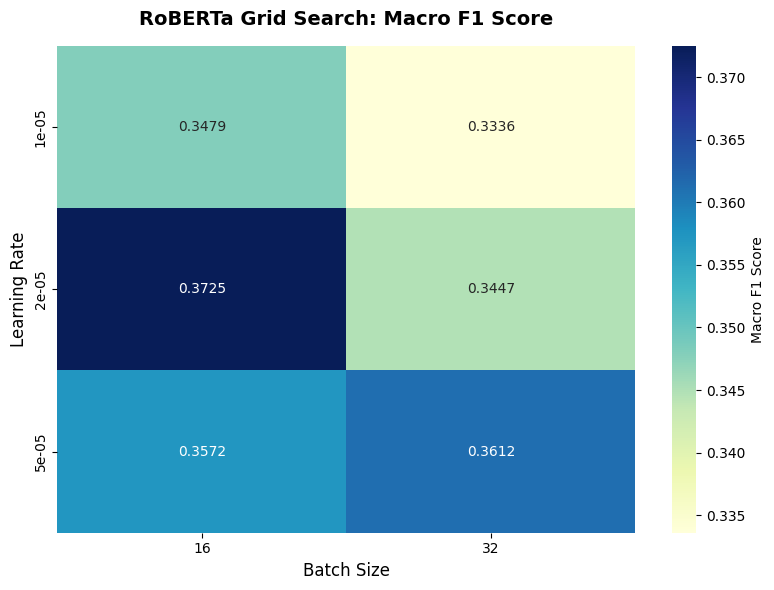

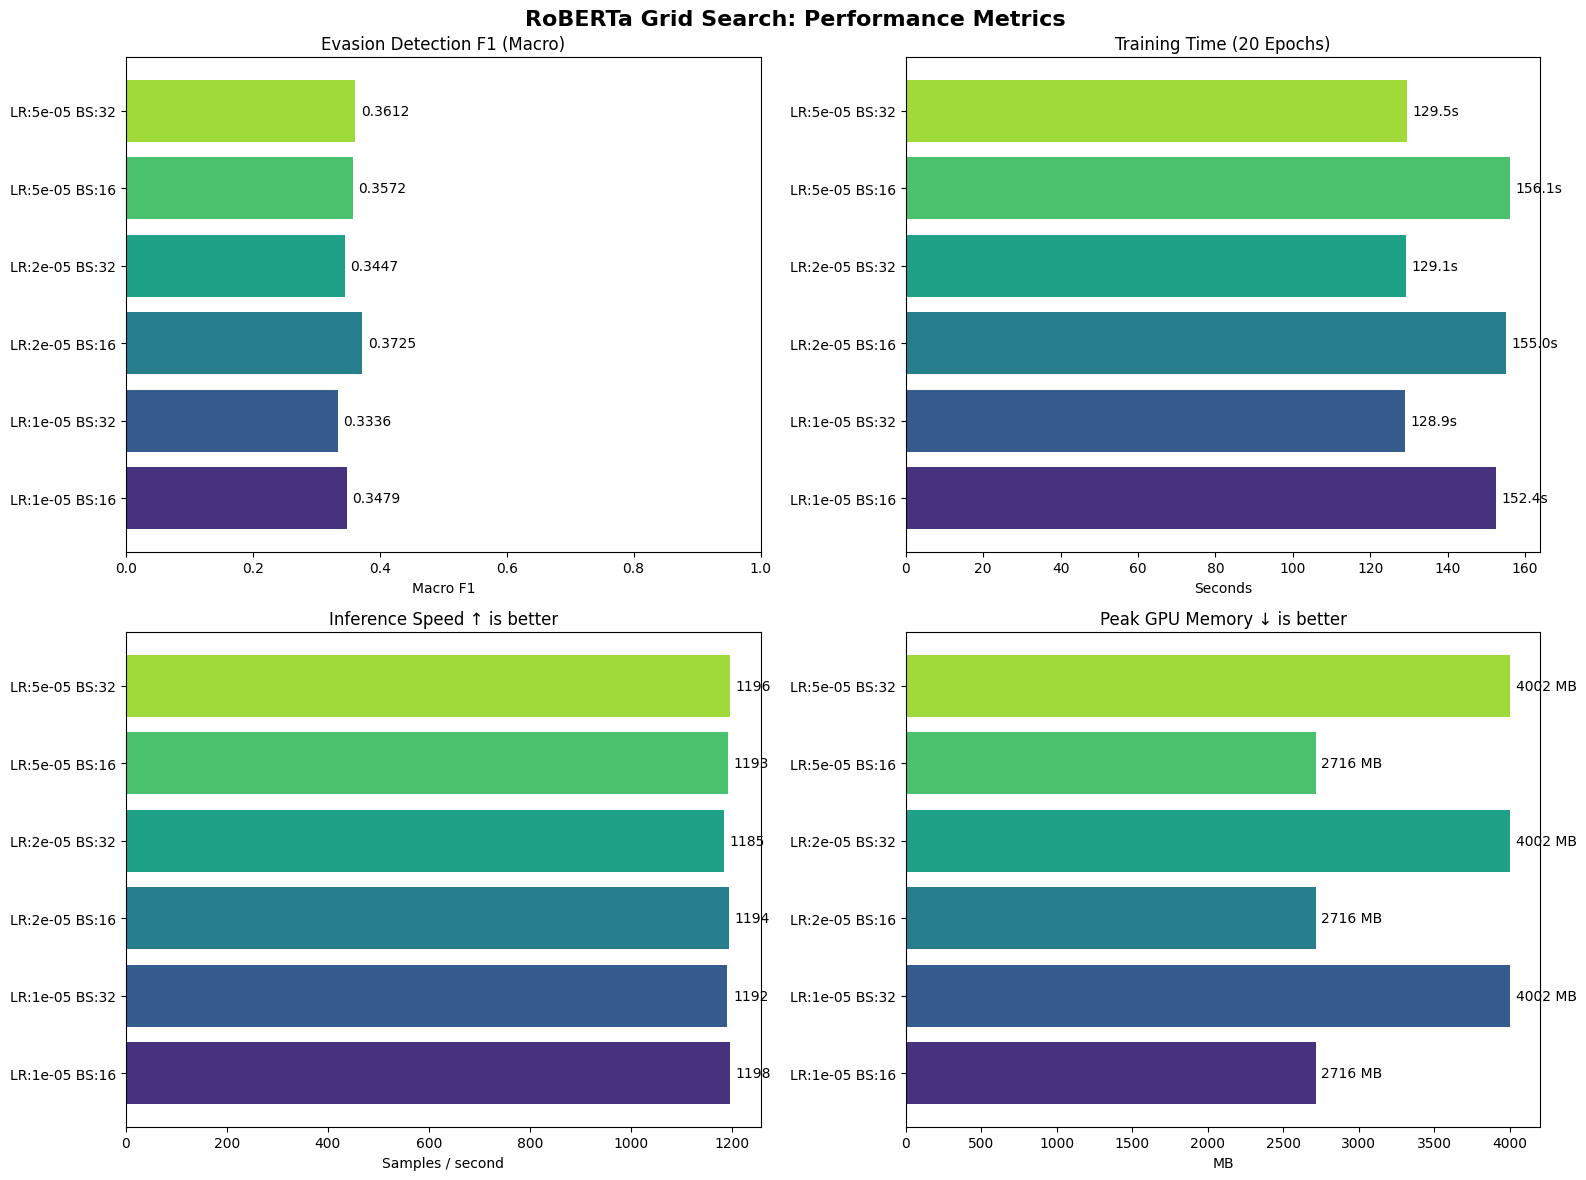


Figures saved → figures/roberta_grid_search_heatmap.png & figures/roberta_grid_search_bars.png
Table  saved → results/roberta_grid_search.csv


In [12]:
tune_df = pd.DataFrame(tuning_results)
tune_df.to_csv("results/roberta_grid_search.csv", index=False)

print("\n\n===== GRID SEARCH RESULTS =====")
print(tune_df[["Learning Rate", "Batch Size", "Evasion F1 (Macro)", "Train Time (s)"]].to_string(index=False))

pivot_f1 = tune_df.pivot(index="Learning Rate", columns="Batch Size", values="Evasion F1 (Macro)")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_f1, annot=True, cmap="YlGnBu", fmt=".4f", cbar_kws={'label': 'Macro F1 Score'})
plt.title("RoBERTa Grid Search: Macro F1 Score", pad=15, fontsize=14, fontweight="bold")
plt.xlabel("Batch Size", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.tight_layout()
plt.savefig("figures/roberta_grid_search_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

tune_df["Config"] = "LR:" + tune_df["Learning Rate"].astype(str) + " BS:" + tune_df["Batch Size"].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("RoBERTa Grid Search: Performance Metrics", fontsize=16, fontweight="bold")

palette = sns.color_palette("viridis", len(tune_df))
configs = tune_df["Config"]

ax = axes[0, 0]
bars = ax.barh(configs, tune_df["Evasion F1 (Macro)"], color=palette)
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlabel("Macro F1")
ax.set_title("Evasion Detection F1 (Macro)")
ax.set_xlim(0, 1.0)

ax = axes[0, 1]
bars = ax.barh(configs, tune_df["Train Time (s)"], color=palette)
ax.bar_label(bars, fmt="%.1fs", padding=4)
ax.set_xlabel("Seconds")
ax.set_title(f"Training Time ({tuning_epochs} Epochs)")

ax = axes[1, 0]
bars = ax.barh(configs, tune_df["Inference Speed (samples/s)"], color=palette)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_xlabel("Samples / second")
ax.set_title("Inference Speed ↑ is better")

ax = axes[1, 1]
bars = ax.barh(configs, tune_df["GPU Memory (MB)"], color=palette)
ax.bar_label(bars, fmt="%.0f MB", padding=4)
ax.set_xlabel("MB")
ax.set_title("Peak GPU Memory ↓ is better")

plt.tight_layout()
plt.savefig("figures/roberta_grid_search_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigures saved → figures/roberta_grid_search_heatmap.png & figures/roberta_grid_search_bars.png")
print("Table  saved → results/roberta_grid_search.csv")